In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import csv
from scipy.optimize import curve_fit

In [12]:
#cleaning up data of first dataset

#seperating the rows in a new list
rows = []

#removing the rows using csv.reader and storing rows in variable rows
with open("decayes_and_neutrons.csv") as i:
    reader = csv.reader(i)
    for row in reader:
        rows.append(row)

#finding the max length of the rows and appendeding new rows so all the rows are standardized (so pandas can read it)
max_length_row = max(len(r) for r in rows)
cleaned = [r + [""] * (max_length_row - len(r)) for r in rows]

#add these new rows to a clean version of the csv file
with open("decayes_and_neutrons_cleaned.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(cleaned)

In [4]:
#converting the csv into a pandas dataframe
df = pd.read_csv("decayes_and_neutrons_cleaned.csv", header=None, sep = ",")

In [13]:
print(df.head())
print(df.shape)
#the first row is momentum and the second row is decay time

        0        1       2   3   4   5   6   7   8   9   ...  17  18  19  20  \
0  55.3855  1.24017     NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
1  40.5978  4.10370     NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
2   0.0000  0.00000  335.04 NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
3  29.8476  0.76665     NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
4  59.4927  9.81459     NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   

   21  22  23  24  25  26  
0 NaN NaN NaN NaN NaN NaN  
1 NaN NaN NaN NaN NaN NaN  
2 NaN NaN NaN NaN NaN NaN  
3 NaN NaN NaN NaN NaN NaN  
4 NaN NaN NaN NaN NaN NaN  

[5 rows x 27 columns]
(1986465, 27)


In [6]:
#only selecting the rows with recorded delay times and detected electrons (non-zero second columns)
decay_times = df[df[1] > 0][1]
decay_times = decay_times[decay_times > 0.2]

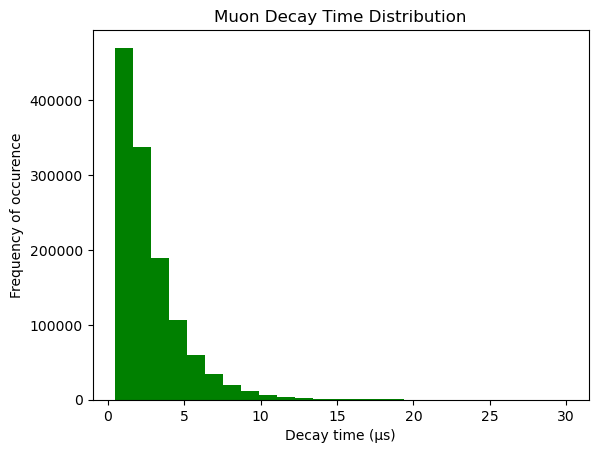

In [17]:
#making a histogram of the frequency of the times the electrons were deteced at
plt.hist(decay_times, bins = 25, color = "green")
plt.xlabel("Decay time (μs)")
plt.ylabel("Frequency of occurence")
plt.title("Muon Decay Time Distribution")
plt.show()

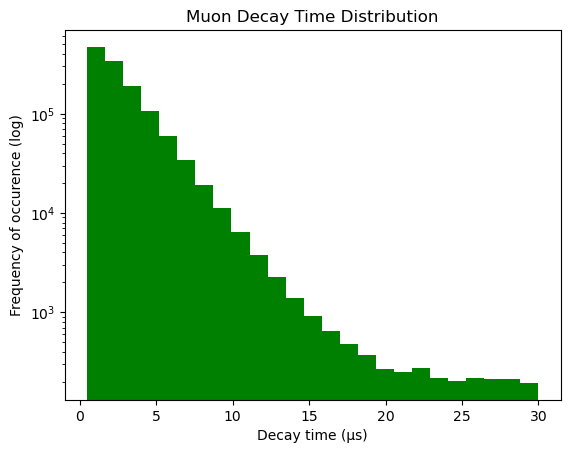

In [16]:
#log scale to help condense the data for easier data analysis
plt.hist(decay_times, bins = 25, log = True, color = "green")
plt.xlabel("Decay time (μs)")
plt.ylabel("Frequency of occurence (log)")
plt.title("Muon Decay Time Distribution")
plt.show()

In [9]:
#exponential fit based on the exponential decay law
def exponential_fit(t, C, tau):
    return C * np.exp(-t/tau)

count, bins = np.histogram(decay_times, bins = 25)
#takes the center of each bin for the exponential fitting
centers = 0.5*(bins[1:] + bins[:-1])

popt, pcov = curve_fit(exponential_fit, centers, count, p0 = [max(count), 2.0])
C_fit, tau_fit = popt
C_err, tau_err = np.sqrt(np.diag(pcov))

print(f"Estimated error on muon lifetime {tau_err}")
print(f"Estimated muon lifetime {tau_fit:.5f} microseconds")


Estimated error on muon lifetime 0.0781181819696739
Estimated muon lifetime 2.46355 microseconds


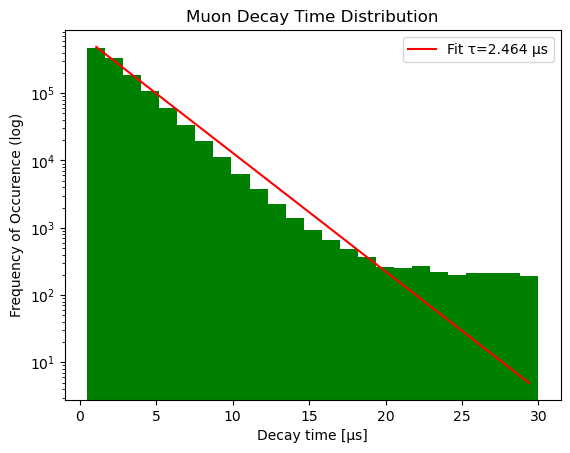

In [10]:
#plotting the histogram together with the line of best fit

plt.hist(decay_times, bins = 25, log = True, color = "green")
plt.plot(centers, exponential_fit(centers, *popt), 'r-', label=f"Fit τ={tau_fit:.3f} μs")
plt.yscale("log")
plt.xlabel("Decay time [μs]")
plt.ylabel("Frequency of Occurence (log)")
plt.title("Muon Decay Time Distribution")
plt.legend()
plt.show()